# Tarea 1: Regresión Lineal, MDS.
Nombre: Patricio Espinoza A

Curso: MDS7104 - Aprendizaje de Maquinas

# Pregunta 3

In [2]:
# Import 
import json, os, math
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# ---------------------------
# (0) Cargar datos y preparar columnas
# ---------------------------
PATH = "Gift_Cards.jsonl"   
SEED = 20918356   

random.seed(SEED)

df = pd.read_json(PATH, lines=True)

# Normalizar
col_map = {
    'rating': ['rating','stars','overall'],
    'verified_purchase': ['verified_purchase','verified'],
    'helpful_vote': ['helpful_vote','helpful_votes','helpful'],
    'text': ['text','review_text','review_body','content'],
    'timestamp': ['timestamp','review_date','date']
}

def ensure_col(df, target, candidates):
    """
    Asegura que la columna 'target' exista en el DataFrame 'df',
    buscando en la lista de 'candidates'.
    """
    for c in candidates:
        if c in df.columns:
            df[target] = df[c]
            return
    if target not in df.columns:
        raise ValueError(f"No se encontró columna para '{target}'. Candidatas: {candidates}")

for k,v in col_map.items():
    ensure_col(df, k, v)
print("Todas las columnas necesarias están presentes.")

# length_of_review: usando conteo de palabras en 'text'
df['length_of_review'] = df['text'].astype(str).str.split().apply(len)

# verified_purchase a 0/1 si no es ya numérico/booleano
if df['verified_purchase'].dtype == 'bool':
    df['verified_purchase'] = df['verified_purchase'].astype(int)
elif df['verified_purchase'].dtype == 'object':
    df['verified_purchase'] = (
        df['verified_purchase'].astype(str)
        .str.strip().str.upper()
        .map({'Y':1,'YES':1,'TRUE':1,'T':1})
        .fillna(0).astype(int)
    )

# helpful_vote a numérico
df['helpful_vote'] = pd.to_numeric(df['helpful_vote'], errors='coerce').fillna(0).astype(int)

# timestamp a datetime 
df['review_date'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
df['year']  = df['review_date'].dt.year
df['month'] = df['review_date'].dt.month

# Filtrado de filas válidas
print(f"Filas originales: {df.shape[0]}")
df = df.dropna(subset=['rating','verified_purchase','helpful_vote','length_of_review'])
df = df[(df['rating']>=1) & (df['rating']<=5)]
print(f"Filas después de filtrar nulos e inválidos: {df.shape[0]}")

# 50% sample con semilla
df_sample = df.sample(frac=0.5, random_state=SEED)
print(f"Filas después de muestreo del 50%: {df_sample.shape[0]}")

Todas las columnas necesarias están presentes.
Filas originales: 152410
Filas después de filtrar nulos e inválidos: 152410
Filas después de muestreo del 50%: 76205


In [38]:
# ---------------------------
# (a) Clase Linear_Regression
# ---------------------------
class Linear_Regression:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.theta_ = None  # intercepto como primer coef si fit_intercept=True

    def _augment(self, X):
        if not self.fit_intercept:
            return X
        n = X.shape[0]
        return np.hstack([np.ones((n,1)), X])
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        Xa = self._augment(X)
        # \hat{theta}_MC = (X^T X)^(-1) X^T y  
        self.theta_ = np.linalg.pinv(Xa) @ y
        #self.theta = (X.T @ X)^{-1} @ X.T
        return self
    
    def predict(self, X):
        # \hat{y} = X \hat{\theta}_MC
        X = np.asarray(X, dtype=float)
        Xa = self._augment(X)
        return Xa @ self.theta_

# Construir X, y base (xvp, xhv, xlr)
base_feats = ['verified_purchase','helpful_vote','length_of_review']
X = df_sample[base_feats].to_numpy()
y = df_sample['rating'].to_numpy()

Distribución calificaciones (conteos):
rating
1     6196
2      938
3     1630
4     3352
5    64089
Name: count, dtype: int64
Porcentaje de cada rating:
rating
1    0.081307
2    0.012309
3    0.021390
4    0.043987
5    0.841008
Name: proportion, dtype: float64

Media rating: 4.551079325503576
Varianza rating: 1.339725260163211


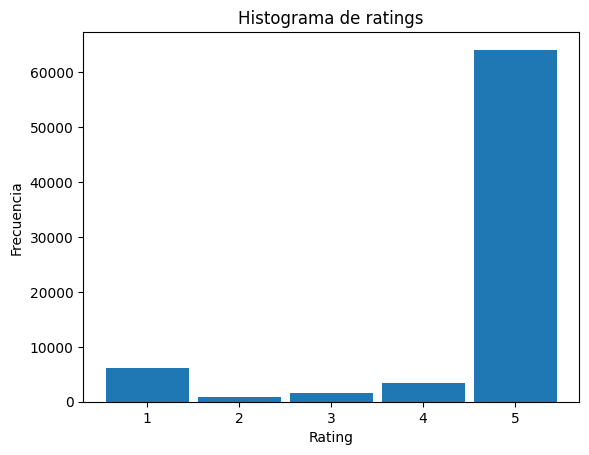

In [39]:
# ---------------------------
# (b) Distribución de calificaciones
# ---------------------------
print("Distribución calificaciones (conteos):")
print(df_sample['rating'].value_counts().sort_index())
# Cuanto porcentaje representa cada rating
print("Porcentaje de cada rating:")
print(df_sample['rating'].value_counts(normalize=True).sort_index())
# Estadísticas descriptivas
print("\nMedia rating:", df_sample['rating'].mean())
print("Varianza rating:", df_sample['rating'].var())
# Grafico
df_sample['rating'].plot(kind='hist', bins=[0.5,1.5,2.5,3.5,4.5,5.5], rwidth=0.9, title='Histograma de ratings')
plt.xlabel('Rating'); plt.ylabel('Frecuencia')
plt.show()

In [41]:
# ---------------------------
# (c) Split 80/20 y MCO
# ---------------------------

# Métricas
def mse(y_true, y_pred): # ECM
    return float(np.mean((y_true - y_pred)**2))
def rmse(y_true, y_pred):
    return math.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot if ss_tot>0 else np.nan

# Split 80/20
rng = np.random.RandomState(SEED)
idx = np.arange(len(df_sample))
rng.shuffle(idx)
split = int(0.8*len(idx))
tr, te = idx[:split], idx[split:]
Xtr, Xte = X[tr], X[te]
ytr, yte = y[tr], y[te]

print(f"Train size: {Xtr.shape[0]}, Test size: {Xte.shape[0]}")

lin = Linear_Regression(fit_intercept=True).fit(Xtr, ytr)
coef = lin.theta_   # [theta0, theta1, theta2, theta3]

print("θ estimados (MCO):")
print(f"θ0={coef[0]:.4f}, θ1(xvp)={coef[1]:.4f}, θ2(xhv)={coef[2]:.4f}, θ3(xlr)={coef[3]:.4f}")

pred_tr = lin.predict(Xtr); pred_te = lin.predict(Xte)
for part, yt, yp in [('Train',ytr,pred_tr), ('Test',yte,pred_te)]:
    print(f"[{part}] RMSE={rmse(yt,yp):.4f}  MSE={mse(yt,yp):.4f}  MAE={mae(yt,yp):.4f}  R2={r2(yt,yp):.4f}")

Train size: 60964, Test size: 15241
θ estimados (MCO):
θ0=4.2110, θ1(xvp)=0.6165, θ2(xhv)=-0.0003, θ3(xlr)=-0.0146
[Train] RMSE=1.0789  MSE=1.1640  MAE=0.6642  R2=0.1242
[Test] RMSE=1.1051  MSE=1.2212  MAE=0.6786  R2=0.1164


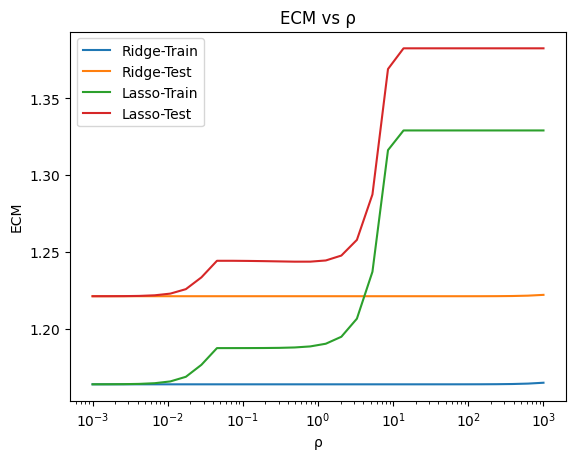

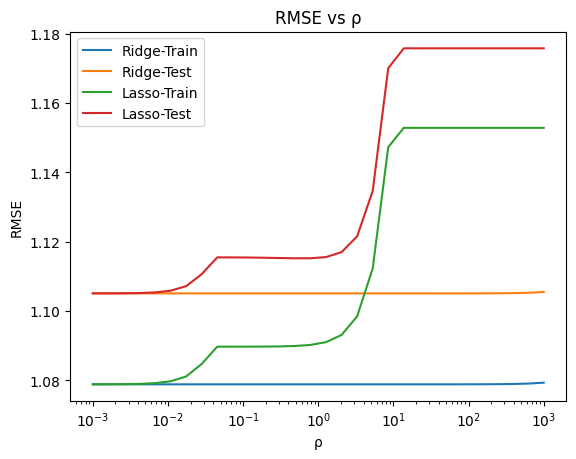

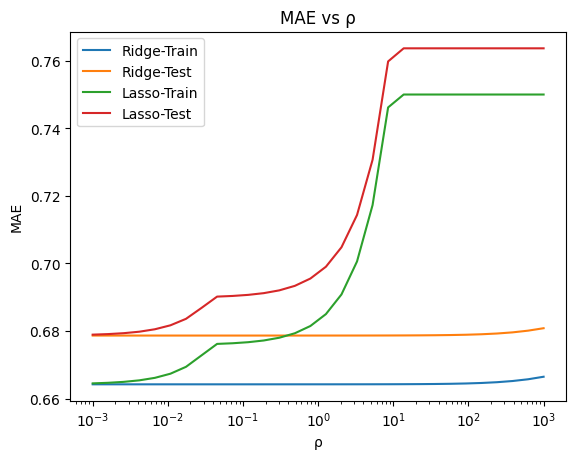

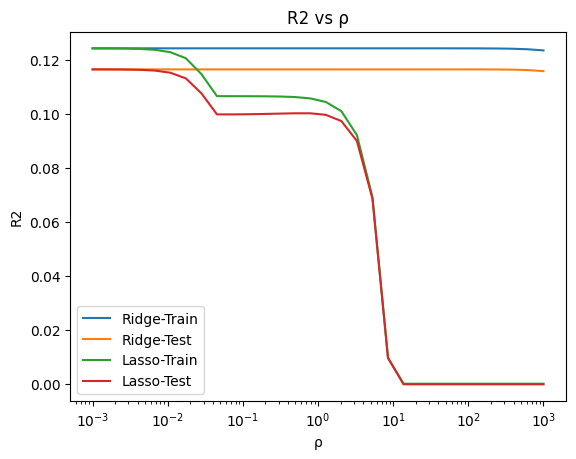

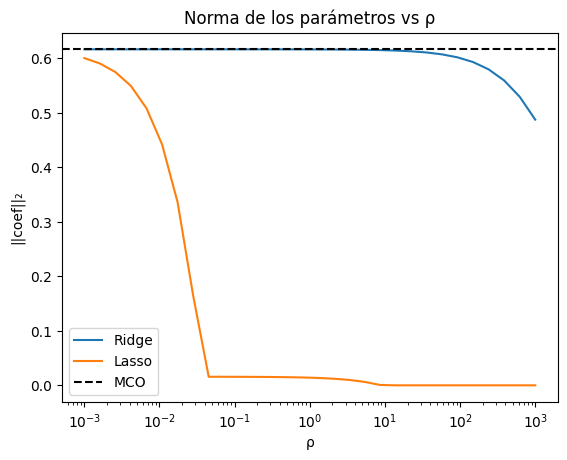

In [ ]:
# ---------------------------
# (d) LASSO y Ridge vs ρ
# ---------------------------
from sklearn.linear_model import Lasso, Ridge

rhos = np.logspace(-3, 3, 30) # 30 valores entre 0.001 y 1000 (log scale)
res = []
for rho in rhos:
    ridge = Ridge(alpha=rho, fit_intercept=True).fit(Xtr, ytr)
    lasso = Lasso(alpha=rho, fit_intercept=True, max_iter=20000).fit(Xtr, ytr)
    for name, model in [('Ridge', ridge), ('Lasso', lasso)]:
        for part, Xt, yt in [('Train', Xtr, ytr), ('Test', Xte, yte)]:
            yp = model.predict(Xt)
            res.append({
                'model': name, 'rho': rho, 'part': part,
                'MSE': mse(yt, yp),
                'RMSE': rmse(yt, yp),
                'MAE': mae(yt, yp),
                'R2': r2(yt, yp),
                'coef_norm_L2': np.linalg.norm(getattr(model,'coef_', np.array([])), 2),
                'n_nonzero': int(np.sum(np.abs(getattr(model,'coef_', np.array([])))>1e-8))
            })
res_df = pd.DataFrame(res)

# Curvas MSE vs rho
for name in ['Ridge','Lasso']:
    sub = res_df[(res_df['model']==name)]
    for part in ['Train','Test']:
        s = sub[sub['part']==part]
        plt.plot(s['rho'], s['MSE'], label=f'{name}-{part}')
plt.xscale('log'); plt.xlabel('ρ'); plt.ylabel('ECM'); plt.title('ECM vs ρ')
plt.legend(); plt.show()

# Norma de coeficientes vs rho
for name in ['Ridge','Lasso']:
    sub = res_df[(res_df['model']==name) & (res_df['part']=='Train')]
    plt.plot(sub['rho'], sub['coef_norm_L2'], label=name)

# Añadir MCO
norm_mco = np.linalg.norm(lin.theta_[1:], 2)  
plt.axhline(y=norm_mco, color='black', linestyle='--', label='MCO')

plt.xscale('log')
plt.xlabel('ρ')
plt.ylabel('||coef||₂')
plt.title('Norma de los parámetros vs ρ')
plt.legend()
plt.show()


Correlaciones entre predictores:
                    verified_purchase  helpful_vote  length_of_review
verified_purchase           1.000000     -0.002330         -0.178679
helpful_vote               -0.002330      1.000000          0.164547
length_of_review           -0.178679      0.164547          1.000000


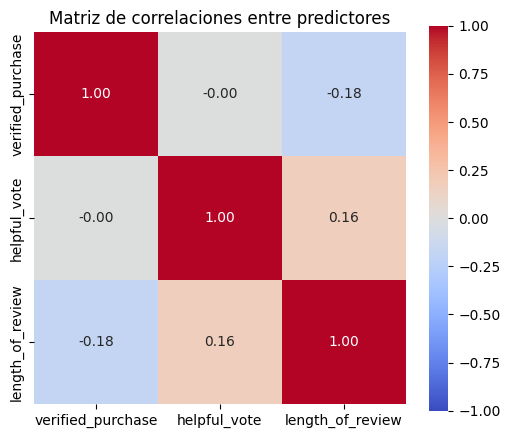

In [ ]:
# ---------------------------
# (e) Matriz de correlaciones entre predictores
# ---------------------------
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd.DataFrame(X, columns=base_feats).corr()
print("\nCorrelaciones entre predictores:\n", corr)

# Graficar como mapa de calor
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True, fmt=".2f")
plt.title("Matriz de correlaciones entre predictores")
plt.show()

θ estimados (MCO):
θ0=4.5546, θ1(xvp)=0.1561, θ2(xhv)=-0.0076, θ3(xlr)=-0.3467
[Scaled Train MCO] RMSE=1.0789 MSE=1.1640 MAE=0.6642 R2=0.1242
[Scaled Test MCO] RMSE=1.1051 MSE=1.2212 MAE=0.6786 R2=0.1164


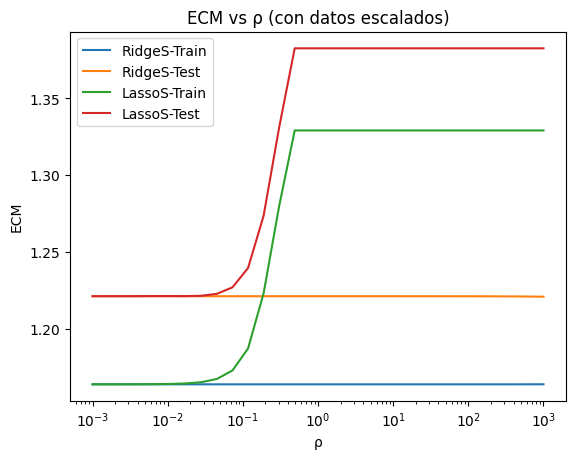

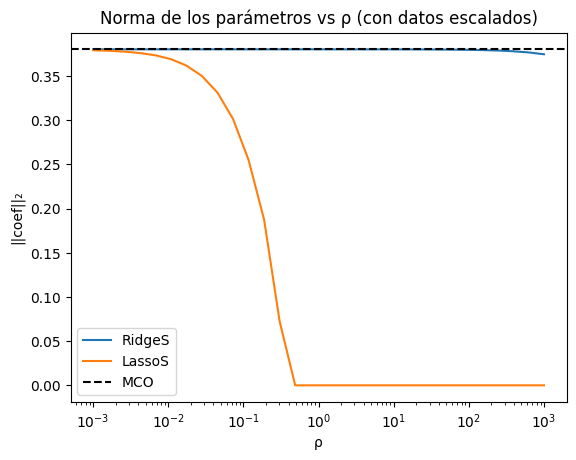

In [ ]:
# ---------------------------
# (f) Repetir con escalado (solo para X)
# ---------------------------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xte_s = scaler.transform(Xte)

lin_s = Linear_Regression(fit_intercept=True).fit(Xtr_s, ytr)
coef = lin_s.theta_  # [theta0, theta1, theta2, theta3]
print("θ estimados (MCO):")
print(f"θ0={coef[0]:.4f}, θ1(xvp)={coef[1]:.4f}, θ2(xhv)={coef[2]:.4f}, θ3(xlr)={coef[3]:.4f}")

for part, Xt, yt in [('Train', Xtr_s, ytr), ('Test', Xte_s, yte)]:
    yp = lin_s.predict(Xt)
    print(f"[Scaled {part} MCO] RMSE={rmse(yt,yp):.4f} MSE={mse(yt,yp):.4f} MAE={mae(yt,yp):.4f} R2={r2(yt,yp):.4f}")

# Ridge/Lasso con X escalada
res_s = []
for rho in rhos:
    ridge = Ridge(alpha=rho, fit_intercept=True).fit(Xtr_s, ytr)
    lasso = Lasso(alpha=rho, fit_intercept=True, max_iter=20000).fit(Xtr_s, ytr)
    for name, model in [('RidgeS', ridge), ('LassoS', lasso)]:
        for part, Xt, yt in [('Train', Xtr_s, ytr), ('Test', Xte_s, yte)]:
            yp = model.predict(Xt)
            res_s.append({
                'model': name, 'rho': rho, 'part': part,
                'MSE': mse(yt, yp), 'RMSE': rmse(yt, yp), 'MAE': mae(yt, yp), 'R2': r2(yt, yp)
            })
res_s = pd.DataFrame(res_s)

# Curvas MSE vs rho (con X escalada)
for name in ['RidgeS','LassoS']:
    sub = res_s[(res_s['model']==name)]
    for part in ['Train','Test']:
        s = sub[sub['part']==part]
        plt.plot(s['rho'], s['MSE'], label=f'{name}-{part}')
plt.xscale('log')
plt.xlabel('ρ')
plt.ylabel('ECM')
plt.title('ECM vs ρ (con datos escalados)')
plt.legend()
plt.show()

# Norma de coeficientes vs rho (con X escalada)
coef_norms = []
for rho in rhos:
    ridge = Ridge(alpha=rho, fit_intercept=True).fit(Xtr_s, ytr)
    lasso = Lasso(alpha=rho, fit_intercept=True, max_iter=20000).fit(Xtr_s, ytr)
    coef_norms.append({
        'rho': rho,
        'RidgeS': np.linalg.norm(ridge.coef_, 2),
        'LassoS': np.linalg.norm(lasso.coef_, 2)
    })
coef_norms = pd.DataFrame(coef_norms)

for name in ['RidgeS','LassoS']:
    plt.plot(coef_norms['rho'], coef_norms[name], label=name)

# Norma de MCO como referencia (usando X escalada)
norm_mco_s = np.linalg.norm(lin_s.theta_[1:], 2)  
plt.axhline(y=norm_mco_s, color='black', linestyle='--', label='MCO')

plt.xscale('log')
plt.xlabel('ρ')
plt.ylabel('||coef||₂')
plt.title('Norma de los parámetros vs ρ (con datos escalados)')
plt.legend()
plt.show()

In [35]:
# ---------------------------
# (g) Agregar month y year; ElasticNet
# ---------------------------
from sklearn.linear_model import ElasticNet

# Añadir mes y agno
feats_my = base_feats + ['month','year']
df_my = df_sample.dropna(subset=['month','year'])
X2 = df_my[feats_my].to_numpy()
y2 = df_my['rating'].to_numpy()

# Split sincronizado
rng2 = np.random.RandomState(SEED)
idx2 = np.arange(len(df_my))
rng2.shuffle(idx2)
split2 = int(0.8*len(idx2))
tr2, te2 = idx2[:split2], idx2[split2:]
X2tr, X2te = X2[tr2], X2[te2]
y2tr, y2te = y2[tr2], y2[te2]

models = {
    'MCO'       : Linear_Regression(fit_intercept=True).fit(X2tr, y2tr),
    'Ridge'     : Ridge(alpha=1.0, fit_intercept=True).fit(X2tr, y2tr),
    'Lasso'     : Lasso(alpha=1.0, fit_intercept=True, max_iter=20000).fit(X2tr, y2tr),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, fit_intercept=True, max_iter=20000).fit(X2tr, y2tr)
}
for name, model in models.items():
    for part, Xt, yt in [('Train',X2tr,y2tr), ('Test',X2te,y2te)]:
        yp = model.predict(Xt)
        print(f"[{name}-{part}] RMSE={rmse(yt,yp):.4f}  MSE={mse(yt,yp):.4f}  MAE={mae(yt,yp):.4f}  R2={r2(yt,yp):.4f}")

# Comentario:
# month/year pueden capturar estacionalidad/tendencias (si existen). Su aporte puede ser limitado
# si la calificación depende sobre todo del producto/experiencia individual.

[MCO-Train] RMSE=1.0673  MSE=1.1392  MAE=0.6550  R2=0.1428
[MCO-Test] RMSE=1.0929  MSE=1.1944  MAE=0.6695  R2=0.1358
[Ridge-Train] RMSE=1.0673  MSE=1.1392  MAE=0.6550  R2=0.1428
[Ridge-Test] RMSE=1.0929  MSE=1.1944  MAE=0.6695  R2=0.1358
[Lasso-Train] RMSE=1.0905  MSE=1.1893  MAE=0.6830  R2=0.1052
[Lasso-Test] RMSE=1.1153  MSE=1.2439  MAE=0.6971  R2=0.1000
[ElasticNet-Train] RMSE=1.0899  MSE=1.1880  MAE=0.6794  R2=0.1062
[ElasticNet-Test] RMSE=1.1152  MSE=1.2437  MAE=0.6935  R2=0.1002


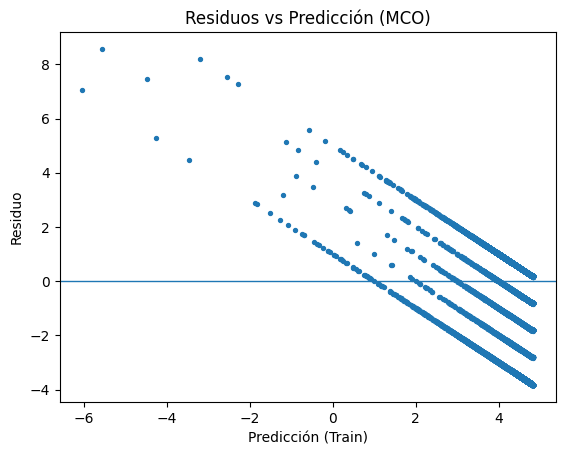

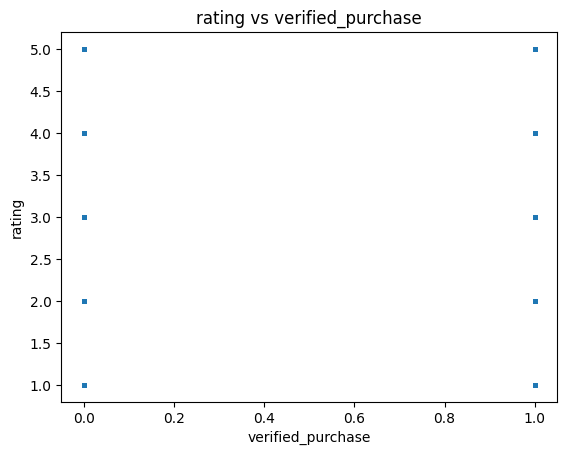

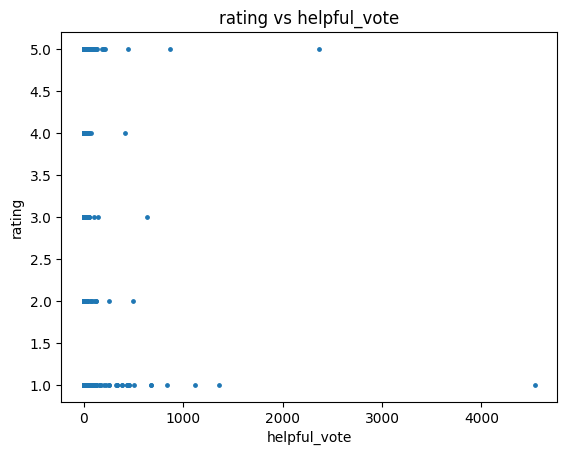

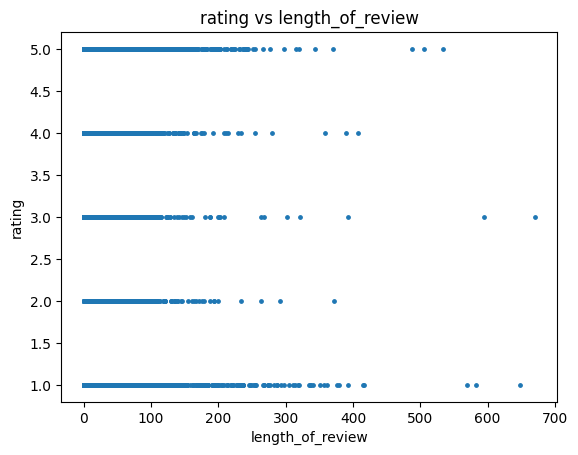

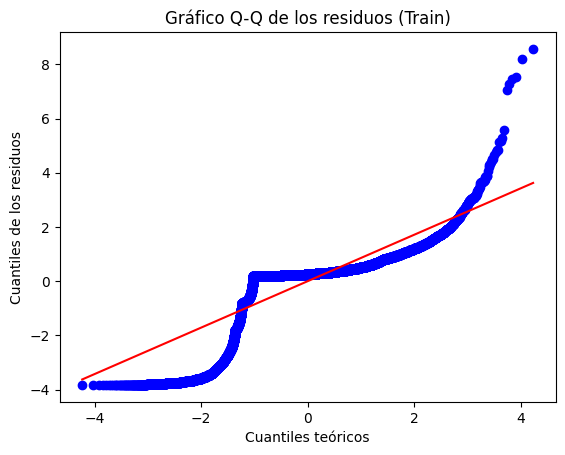

In [43]:
# ---------------------------
# (i) BONUS: Validación de supuestos
# ---------------------------
# Residuos vs predicciones (homocedasticidad)
yp_tr = lin.predict(Xtr)
resid = ytr - yp_tr
plt.scatter(yp_tr, resid, s=8)
plt.axhline(0, lw=1)
plt.xlabel('Predicción (Train)'); plt.ylabel('Residuo')
plt.title('Residuos vs Predicción (MCO)')
plt.show()

# Dispersión predictores vs rating (linealidad)
for j, col in enumerate(base_feats):
    plt.scatter(df_sample[col].values[tr], ytr, s=6)
    plt.xlabel(col); plt.ylabel('rating'); plt.title(f'rating vs {col}')
    plt.show()

# Q-Q plot (normalidad de errores)
import matplotlib.pyplot as plt
import scipy.stats as st

st.probplot(resid, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de los residuos (Train)')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles de los residuos')
plt.show()
